In [4]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
%pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


                           Coluna  Média  Mediana  Moda  Q1 (25%)  Q3 (75%)  \
0                             age  38.01    38.00  47.0     27.00     49.00   
1                 months_inactive   1.53     1.00   0.0      0.00      2.00   
2  music_suggestion_rating_1_to_5   3.64     4.00   4.0      3.00      5.00   
3    avg_listening_hours_per_week   9.99     9.98   0.0      7.28     12.68   
4               playlists_created   8.00     8.00   7.0      6.00     10.00   
5               avg_skips_per_day  10.03    10.00  10.0      8.00     12.00   

   Amplitude  Variância  Desvio Padrão  CV (%)  
0      44.00     168.61          12.98   34.16  
1      18.00       3.81           1.95  127.34  
2       4.00       1.24           1.11   30.58  
3      26.25      15.75           3.97   39.73  
4      23.00       8.02           2.83   35.38  
5      24.00      10.02           3.17   31.57  


C:\Users\leoha\AppData\Local\Temp\ipykernel_13004\953231418.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='subscription_type', y='age', data=df, palette='viridis')
C:\Users\leoha\AppData\Local\Temp\ipykernel_13004\953231418.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='music_suggestion_rating_1_to_5', data=df, palette='magma')


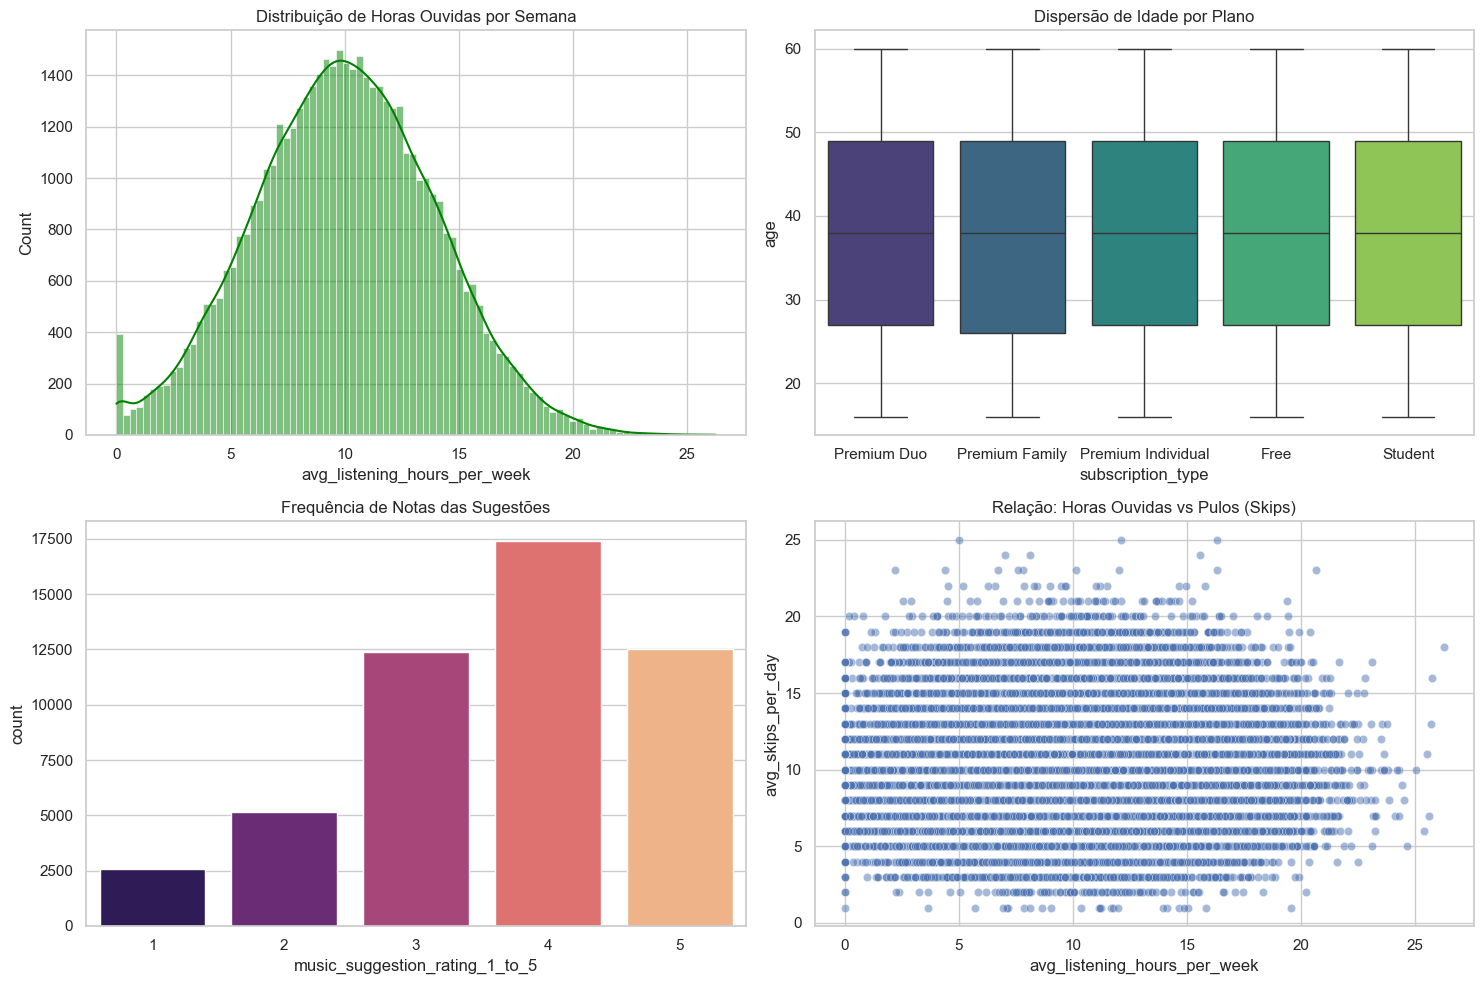

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregar o dataset
df = pd.read_csv('spotify_user_behavior.csv') # Ajuste o nome do arquivo se necessário

# Selecionando apenas as colunas quantitativas descritas nos seus metadados
colunas_quant = [
    'age', 'months_inactive', 'music_suggestion_rating_1_to_5', 
    'avg_listening_hours_per_week', 'playlists_created', 'avg_skips_per_day'
]

def calcular_estatisticas(df, colunas):
    resultados = []
    
    for col in colunas:
        # Medidas de Posição
        media = df[col].mean()
        mediana = df[col].median()
        moda = df[col].mode()[0]
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        
        # Medidas de Dispersão
        amplitude = df[col].max() - df[col].min()
        variancia = df[col].var()
        desvio_padrao = df[col].std()
        cv = (desvio_padrao / media) * 100 if media != 0 else 0
        
        resultados.append({
            'Coluna': col,
            'Média': round(media, 2),
            'Mediana': mediana,
            'Moda': moda,
            'Q1 (25%)': q1,
            'Q3 (75%)': q3,
            'Amplitude': amplitude,
            'Variância': round(variancia, 2),
            'Desvio Padrão': round(desvio_padrao, 2),
            'CV (%)': round(cv, 2)
        })
    
    return pd.DataFrame(resultados)

# Executar cálculos
tabela_estatistica = calcular_estatisticas(df, colunas_quant)
print(tabela_estatistica)

# --- GERAÇÃO DE GRÁFICOS ---

# Configuração visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 10))

# 1. Histograma de Horas Ouvidas (Distribuição)
plt.subplot(2, 2, 1)
sns.histplot(df['avg_listening_hours_per_week'], kde=True, color='green')
plt.title('Distribuição de Horas Ouvidas por Semana')

# 2. Boxplot de Idade por Tipo de Assinatura (Separatrizes e Outliers)
plt.subplot(2, 2, 2)
sns.boxplot(x='subscription_type', y='age', data=df, palette='viridis')
plt.title('Dispersão de Idade por Plano')

# 3. Gráfico de Barras: Avaliação do Algoritmo (Frequência/Moda)
plt.subplot(2, 2, 3)
sns.countplot(x='music_suggestion_rating_1_to_5', data=df, palette='magma')
plt.title('Frequência de Notas das Sugestões')

# 4. Dispersão: Horas Ouvidas vs Skips por Dia (Correlação)
plt.subplot(2, 2, 4)
sns.scatterplot(x='avg_listening_hours_per_week', y='avg_skips_per_day', alpha=0.5, data=df)
plt.title('Relação: Horas Ouvidas vs Pulos (Skips)')

plt.tight_layout()
plt.show()